# Algumas ferramentas Importantes


## Ciclo de vida do Software
- Escopo -> Design -> Buid -> Testing -> Deploy


## Escopo
- A soma dos produtos, serviços e/ou resultados que se espera alcançar ao final do projeto.


## 5W2h
* Oquê?
* Porquê?
* Como?
* Quando?
* Onde?
* Quem?
* Quanto custa?

# A missão do ciêntista de dados:
- Extrair conhecimento de dados desorganizados.


# AGEMC

- Ask
- Get
- Explorer
- Model
- Comunicate (A unica parte que o cliente vê)

# Método Hipotético Dedutivo.
É interessante lembrar que as coisas, na maioria das vezes, não são tão objetivas,
tão bem acertadas, e a abordagem analítica, a que divide para conquistar, nem sempre é a melhor alternativa. Na maioria dos casos é preciso empregarmos uma visão sistemica, aquela que percebe o mundo mais como uma Mass, cheio de várias formas e cores.

## Parte 1.
Geralmente as coisas se iniciam por aqui.
- Observação
- Pergunta
- Pesquisa

## Parte 2.
Quando a primeira parte ocorre do jeito certo chegamos
a esta parte.

- Hipótese
- Extração dos dados
- Análise dos dados
- Análise dos dados


## Parte 3.

- Conclusão.


Pergunta:

Qual o efeito de um período de taxas de juros elevadas nos princípais índices econômicos de um país, geração de postos diretos de trabalho, aprimoramento da capacidade produtiva, geração de empresas.

Obtenção dos dados:

Quais os dados que eu preciso?
- Série histórica das taxas de juros.
- Série histórica de inflação.

In [1]:
# Minha chave de API do FRED (Federal Reserve Data)

API_KEY = "9294d3fde27c9136f028ca04240fbc94"

In [2]:
%%capture
!pip install fredapi

In [3]:
from fredapi import Fred
import pandas as pd

# Inicialize o cliente com sua chave gratuita
fred = Fred(api_key=API_KEY)

# 1. Taxa Básica de Juros (Federal Funds Effective Rate)
fed_funds = fred.get_series('FEDFUNDS')

# 2. Inflação - CPI Total (Consumer Price Index)
cpi = fred.get_series('CPIAUCSL')

# 3. Inflação - Núcleo do CPI (Core CPI, excluindo alimentos e energia)
core_cpi = fred.get_series('CPILFESL')

# 4. Inflação - PCE (Personal Consumption Expenditures - a métrica oficial do Fed)
pce = fred.get_series('PCEPI')

# 5. Outros Indicadores Macroeconômicos Relevantes
unemployment = fred.get_series('UNRATE')       # Taxa de Desemprego
gdp = fred.get_series('GDP')                   # PIB Nominal (Trimestral)
yield_10y = fred.get_series('GS10')             # Juros dos T-Bills de 10 anos

# Consolidando em um único DataFrame
df = pd.DataFrame({
    'Fed_Funds': fed_funds,
    'CPI': cpi,
    'Core_CPI': core_cpi,
    'PCE': pce,
    'Unemployment': unemployment
}).dropna()

print(df.tail())

            Fed_Funds      CPI  Core_CPI      PCE  Unemployment
2026-03-01       3.64  330.293   334.165  130.403           4.3
2026-04-01       3.64  332.407   335.423  130.946           4.3
2026-05-01       3.63  333.979   336.121  131.576           4.3
2026-06-01       3.63  332.568   336.065  131.454           4.2
2026-07-01       3.63  332.813   336.789  131.659           4.1


In [4]:
from fredapi import Fred
import pandas as pd

In [8]:
# Inicialize o cliente com sua chave gratuita
fred = Fred(api_key=API_KEY)

# 1. Taxa Básica de Juros (Federal Funds Effective Rate)
fed_funds = fred.get_series('FEDFUNDS')

In [9]:
df = pd.DataFrame({"taxa_juros": fed_funds}).reset_index()

In [10]:
df['date_time'] = df['index']

In [11]:
df.head()

,index,taxa_juros,date_time
0,1954-07-01,0.80,1954-07-01
1,1954-08-01,1.22,1954-08-01
2,1954-09-01,1.07,1954-09-01
3,1954-10-01,0.85,1954-10-01
4,1954-11-01,0.83,1954-11-01


In [12]:
df.drop(columns= ['index'], inplace= True)

In [13]:
df.head(10)

,taxa_juros,date_time
0,0.80,1954-07-01
1,1.22,1954-08-01
2,1.07,1954-09-01
3,0.85,1954-10-01
4,0.83,1954-11-01
5,1.28,1954-12-01
6,1.39,1955-01-01
7,1.29,1955-02-01
8,1.35,1955-03-01
9,1.43,1955-04-01


In [14]:
df.sample(10)

,taxa_juros,date_time
726,0.11,2015-01-01
797,0.09,2020-12-01
75,2.47,1960-10-01
649,2.00,2008-08-01
700,0.16,2012-11-01
475,3.25,1994-02-01
273,4.73,1977-04-01
281,6.56,1977-12-01
377,8.27,1985-12-01
229,10.50,1973-08-01


In [15]:
# Qual o período onde a econômia americana enfrentou as maiores taxas de juros?

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   taxa_juros  866 non-null    float64       
 1   date_time   866 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 13.7 KB


In [17]:
df.describe()

,taxa_juros,date_time
count,866.00000,866
mean,4.59485,1990-07-17 00:28:16.073902976
min,0.05000,1954-07-01 00:00:00
25%,1.93500,1972-07-08 18:00:00
50%,4.25500,1990-07-16 12:00:00
75%,6.11500,2008-07-24 06:00:00
max,19.10000,2026-08-01 00:00:00
std,3.52771,NaN


In [18]:
df['taxa_juros'].max()

19.1

In [19]:
df[df['taxa_juros'] > 7]

,taxa_juros,date_time
177,7.41,1969-04-01
178,8.67,1969-05-01
179,8.90,1969-06-01
180,8.61,1969-07-01
181,9.19,1969-08-01
...,...,...
433,8.13,1990-08-01
434,8.20,1990-09-01
435,8.11,1990-10-01
436,7.81,1990-11-01


In [20]:
df['year'] = df['date_time'].dt.year

In [ ]:
df.tail()

,taxa_juros,date_time,year
861,3.64,2026-04-01,2026
862,3.63,2026-05-01,2026
863,3.63,2026-06-01,2026
864,3.63,2026-07-01,2026
865,3.63,2026-08-01,2026


In [ ]:
df.columns

Index(['taxa_juros', 'date_time', 'year'], dtype='object')

In [21]:
df.rename(columns= {'taxa_juros': 'rates'}, inplace= True)

In [22]:
# Agrupando os anos e verificando a maior, menor e a taxa média de cada ano.

df_agrupando_taxas = df.groupby('year').agg({
    'rates': ['min', 'max', 'mean']
}).reset_index()

In [23]:
df_agrupando_taxas['rates']['mean'].max()

16.378333333333334

In [24]:
df_agrupando_taxas[df_agrupando_taxas['rates']['mean'] >= 15]

year  rates                 
            min   max       mean
27  1981  12.37  19.1  16.378333

In [25]:
df_agrupado = df.groupby('year').agg({
    "rates": ['min', 'max', 'mean']
}).reset_index()

In [26]:
ano_1981 = df[df['year'] == 1981].copy()

In [27]:
ano_1981.head()

,rates,date_time,year
318,19.08,1981-01-01,1981
319,15.93,1981-02-01,1981
320,14.70,1981-03-01,1981
321,15.72,1981-04-01,1981
322,18.52,1981-05-01,1981


In [34]:
df.rename(columns= {"date_time": "datetime"}, inplace= True)

In [37]:
ano_1981 = df[df['year'] == 1981].copy()

In [38]:
ano_1981.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 318 to 329
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   rates     12 non-null     float64       
 1   datetime  12 non-null     datetime64[ns]
 2   year      12 non-null     int32         
dtypes: datetime64[ns](1), float64(1), int32(1)
memory usage: 336.0 bytes


In [32]:
import matplotlib.pyplot as plt

In [36]:
df.columns

Index(['rates', 'datetime', 'year'], dtype='object')

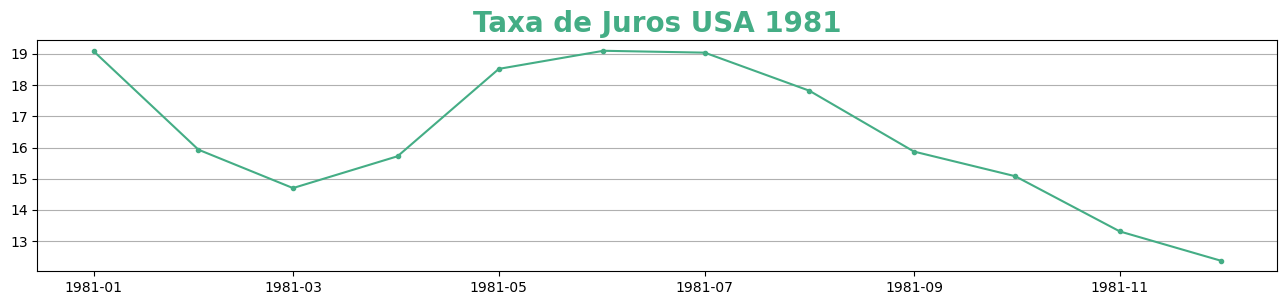

In [39]:
plt.figure(figsize= (16, 3))

plt.plot(ano_1981['datetime'], ano_1981['rates'], marker= '.', color= '#44ad85')

plt.grid(True, linestyle= '-', axis= 'y')

plt.title(
          "Taxa de Juros USA 1981",
          fontfamily= 'sans-serif',
          fontsize= 20,
          fontweight= 'bold',
          color= '#44ad85'
          )


# Como a taxa básica variou nos anos 1979 -> 1985
# E como os índices de inflação andaram, no mesmo período?

plt.show()

In [40]:
# Índice de preços do consumidor
cip = fred.get_series('CPIAUCSL')

In [42]:
# Taxa básica de juros
rate = fred.get_series('FEDFUNDS')

In [45]:
# PIB nominal
gdp = fred.get_series('GDP')

In [49]:
gpd

,0
1946-01-01,NaN
1946-04-01,NaN
1946-07-01,NaN
1946-10-01,NaN
1947-01-01,243.164
...,...
2025-04-01,30485.729
2025-07-01,31098.027
2025-10-01,31422.526
2026-01-01,31865.721


In [52]:
gpd['2025-10-01']

np.float64(31422.526)

In [47]:
type(gdp)

pandas.core.series.Series

In [117]:
# Criando um DF com as taxas de juros
df_1 = pd.DataFrame({
    "rate": rate,
    "gdp": gdp,
    "cip": cip
}).reset_index()

In [56]:
df_1.rate.first_valid_index()

Timestamp('1954-07-01 00:00:00')

In [60]:
df_1.head()

,index,rate,gdp,cip
0,1946-01-01,NaN,NaN,NaN
1,1946-04-01,NaN,NaN,NaN
2,1946-07-01,NaN,NaN,NaN
3,1946-10-01,NaN,NaN,NaN
4,1947-01-01,NaN,243.164,21.48


In [62]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   index   960 non-null    datetime64[ns]
 1   rate    866 non-null    float64       
 2   gdp     318 non-null    float64       
 3   cip     954 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 30.1 KB


In [63]:
df_1.describe()

,index,rate,gdp,cip
count,960,866.00000,318.000000,954.000000
mean,1986-08-15 19:45:00,4.59485,7904.209107,125.367268
min,1946-01-01 00:00:00,0.05000,243.164000,21.480000
25%,1966-08-24 06:00:00,1.93500,836.019000,32.885000
50%,1986-08-16 12:00:00,4.25500,4632.648000,110.100000
75%,2006-08-08 18:00:00,6.11500,13840.997000,201.975000
max,2026-08-01 00:00:00,19.10000,32486.066000,333.979000
std,NaN,3.52771,8367.034582,90.626711


In [66]:
(333.9790 / 21.48) * 100

1554.837057728119

In [121]:
df_1.rename(columns= {"index": "data"}, inplace= True)

In [71]:
df_1.columns

Index(['data', 'rate', 'gdp', 'cip'], dtype='object')

In [76]:
df_1.head()

,data,rate,gdp,cip
0,1946-01-01,NaN,NaN,NaN
1,1946-04-01,NaN,NaN,NaN
2,1946-07-01,NaN,NaN,NaN
3,1946-10-01,NaN,NaN,NaN
4,1947-01-01,NaN,243.164,21.48


In [77]:
df_1.tail()

,data,rate,gdp,cip
955,2026-04-01,3.64,32486.066,332.407
956,2026-05-01,3.63,NaN,333.979
957,2026-06-01,3.63,NaN,332.568
958,2026-07-01,3.63,NaN,332.813
959,2026-08-01,3.63,NaN,NaN


In [78]:
df_1.sample(10)

,data,rate,gdp,cip
166,1960-07-01,3.23,545.604,29.55
284,1970-05-01,7.95,NaN,38.60
235,1966-04-01,4.67,804.981,32.28
187,1962-04-01,2.78,600.366,30.21
43,1950-04-01,NaN,290.383,23.65
719,2006-08-01,5.25,NaN,203.80
173,1961-02-01,2.54,NaN,29.84
258,1968-03-01,5.05,NaN,34.30
802,2013-07-01,0.09,16953.838,232.90
224,1965-05-01,4.10,NaN,31.48


In [122]:
df_1['year'] = df_1['data'].dt.year

In [123]:
df_1.rename(columns= {"data": "datetime"}, inplace= True)

In [124]:
# Filtrando 10 anos

recorte = df_1[(df['year'] >=  1975) & (df_1['year'] <= 1985)]

In [94]:
recorte

,datetime,rate,gdp,cip,year
246,1967-03-01,4.53,NaN,33.0,1967
247,1967-04-01,4.05,848.983,33.1,1967
248,1967-05-01,3.94,NaN,33.1,1967
249,1967-06-01,3.98,NaN,33.3,1967
250,1967-07-01,3.79,865.233,33.4,1967
...,...,...,...,...,...
467,1985-08-01,7.90,NaN,107.9,1985
468,1985-09-01,7.92,NaN,108.1,1985
469,1985-10-01,7.99,4444.094,108.5,1985
470,1985-11-01,8.05,NaN,109.0,1985


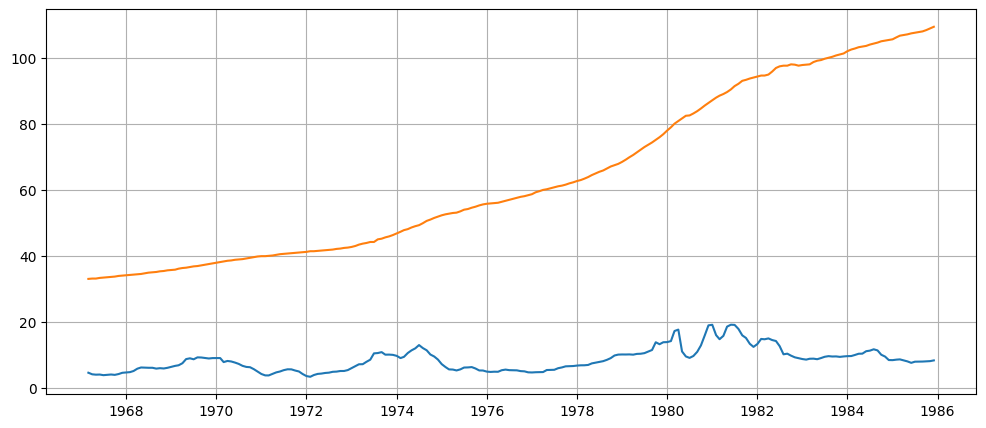

In [101]:
plt.figure(figsize= (12, 5))

plt.plot(recorte['datetime'], recorte['rate'])

# Inflação, pontos.
plt.plot(recorte['datetime'], recorte['cip'])

plt.grid(True)

In [ ]:
# Eu tenho que encontrar a inflação anual

In [125]:
inflacao_media = df_1.groupby('year').agg({
    "cip": ['min', 'max', 'mean']
}).reset_index()

In [109]:
#
df_1['indicesm'] = inflacao_media['cip']['mean'].loc[2] / inflacao_media['cip']['mean'].loc[1]

np.float64(1.0767221434435406)

In [100]:
40 / 100

0.4

In [110]:
from typing import List

In [111]:
import numpy as np

In [129]:
inflacao_media

year      cip                     
              min      max        mean
0   1946      NaN      NaN         NaN
1   1947   21.480   23.410   22.331667
2   1948   23.500   24.430   24.045000
3   1949   23.610   24.010   23.809167
4   1950   23.510   24.980   24.062500
..   ...      ...      ...         ...
76  2022  282.543  298.832  292.626417
77  2023  300.420  308.741  304.703000
78  2024  309.698  317.604  313.698167
79  2025  318.961  326.031  321.961909
80  2026  326.588  333.979  330.872571

[81 rows x 4 columns]

In [132]:
inflacoes:List[float] = []


for n in range(1, inflacao_media['cip']['mean'].count()):
  inflacoes.append(inflacao_media['cip']['mean'].loc[n] / inflacao_media['cip']['mean'].loc[n - 1])


inflacao_media['inflacao_media'] = np.array(inflacoes)

ValueError: Length of values (79) does not match length of index (81)